In [1]:
"""
SMS Spam Classification using Ensemble Methods
Dataset loaded from uploaded file
"""

# IMPORTS

import numpy as np
import pandas as pd

from google.colab import files

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    make_scorer
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


# PARAMETERS

KFOLD = 5
RANDOM_STATE = 42


# UPLOAD DATA FILE

print("Upload SMSSpamCollection file (tab-separated)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Dataset format: label \t message
df = pd.read_csv(
    filename,
    sep="\t",
    header=None,
    names=["label", "message"]
)

df["label"] = df["label"].map({"ham": 0, "spam": 1})
df = df.dropna()

X = df["message"]
y = df["label"]

print("\nDataset loaded successfully!")
print(df.head())


# STRATIFIED K-FOLD

skf = StratifiedKFold(
    n_splits=KFOLD,
    shuffle=True,
    random_state=RANDOM_STATE
)

precision_scorer = make_scorer(precision_score)
recall_scorer = make_scorer(recall_score)
f1_scorer = make_scorer(f1_score)
roc_scorer = make_scorer(roc_auc_score)


# TF-IDF

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)


# BASE MODELS

nb = Pipeline([
    ("tfidf", tfidf),
    ("clf", MultinomialNB())
])

lr = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(max_iter=1000))
])

svm = Pipeline([
    ("tfidf", tfidf),
    ("clf", LinearSVC())
])


# VOTING

voting_hard = VotingClassifier(
    estimators=[
        ("nb", nb),
        ("lr", lr),
        ("svm", svm)
    ],
    voting="hard"
)

voting_soft = VotingClassifier(
    estimators=[
        ("nb", Pipeline([("tfidf", tfidf), ("clf", MultinomialNB())])),
        ("lr", Pipeline([("tfidf", tfidf), ("clf", LogisticRegression(max_iter=1000))]))
    ],
    voting="soft"
)


# STACKING

stacking = StackingClassifier(
    estimators=[
        ("nb", MultinomialNB()),
        ("lr", LogisticRegression(max_iter=1000))
    ],
    final_estimator=LogisticRegression()
)

stacking_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("clf", stacking)
])


# ADABOOST (Decision Stumps)

stump = DecisionTreeClassifier(max_depth=1)

adaboost = Pipeline([
    ("tfidf", tfidf),
    ("clf", AdaBoostClassifier(
        estimator=stump,
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])


# MODEL DICTIONARY

models = {
    "NaiveBayes": nb,
    "LogisticRegression": lr,
    "LinearSVM": svm,
    "Voting_Hard": voting_hard,
    "Voting_Soft": voting_soft,
    "Stacking": stacking_pipeline,
    "AdaBoost_Stumps": adaboost
}


# CROSS VALIDATION

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=skf,
        scoring={
            "precision": precision_scorer,
            "recall": recall_scorer,
            "f1": f1_scorer,
            "roc_auc": roc_scorer
        },
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Precision_mean": scores["test_precision"].mean(),
        "Precision_std": scores["test_precision"].std(),
        "Recall_mean": scores["test_recall"].mean(),
        "Recall_std": scores["test_recall"].std(),
        "F1_mean": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(),
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std()
    })

cv_results = pd.DataFrame(results)
cv_results.to_csv("ensemble_comparison.csv", index=False)

print("\n===== CROSS VALIDATION RESULTS =====")
print(cv_results)


# CONFUSION MATRIX (BEST MODEL)


best_model_name = cv_results.sort_values("F1_mean", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = cross_val_predict(best_model, X, y, cv=skf)

cm = confusion_matrix(y, y_pred)

print(f"\nBest Model: {best_model_name}")
print("\nConfusion Matrix:")
print(cm)


# TRAIN BEST MODEL ON FULL DATA

best_model.fit(X, y)

if hasattr(best_model, "predict_proba"):
    probabilities = best_model.predict_proba(X)[:, 1]
else:
    try:
        probabilities = best_model.decision_function(X)
    except:
        probabilities = np.zeros(len(X))

final_preds = best_model.predict(X)

final_df = pd.DataFrame({
    "MessageId": np.arange(len(X)),
    "Actual": y,
    "Predicted": final_preds,
    "Probability": probabilities
})

final_df.to_csv("final_model_predictions.csv", index=False)

print("\n===== FINAL PREDICTIONS (First 5 Rows) =====")
print(final_df.head())

print("\n Files saved successfully:")
print(" ensemble_comparison.csv")
print(" final_model_predictions.csv")


# RECOMMENDATION

print("\n===== RECOMMENDATION =====")
print(
    "Soft Voting or Stacking typically performs best because they combine "
    "linear and probabilistic decision boundaries effectively. "
    "AdaBoost with decision stumps is weaker in high-dimensional TF-IDF "
    "space compared to linear models."
)


Upload SMSSpamCollection file (tab-separated)


Saving SMSSpamCollection to SMSSpamCollection

Dataset loaded successfully!
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

===== CROSS VALIDATION RESULTS =====
                Model  Precision_mean  Precision_std  Recall_mean  Recall_std  \
0          NaiveBayes        0.996732       0.004005     0.817933    0.024808   
1  LogisticRegression        0.985976       0.008900     0.757664    0.018074   
2           LinearSVM        0.985542       0.009916     0.895553    0.029981   
3         Voting_Hard        0.993770       0.005748     0.850058    0.016828   
4         Voting_Soft        0.994929       0.006773     0.793834    0.009970   
5            Stacking        0.983712   

In [2]:
!pip install -q pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 68.3 MB/s eta 0:00:00


Saving 23102B0005 ML SDP E6.pdf to 23102B0005 ML SDP E6.pdf
Total pages: 1
--- Page 1 ---


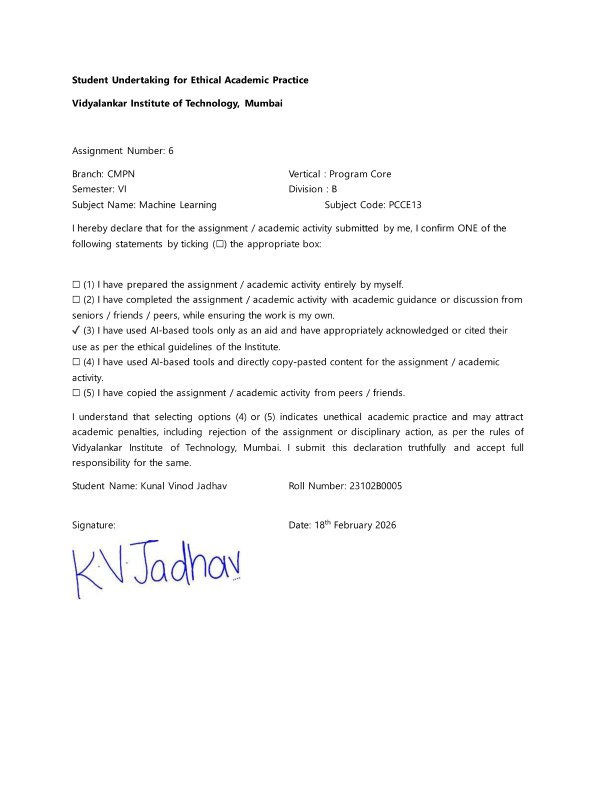

In [3]:

from google.colab import files
import fitz
from IPython.display import display, Image

# Step 1: Upload PDF
uploaded = files.upload()
pdf_file = list(uploaded.keys())[0]

# Step 2: Open PDF
pdf = fitz.open(pdf_file)
print("Total pages:", len(pdf))

# Step 3: Convert each page to image and display
for page_num, page in enumerate(pdf, start=1):
    print(f"--- Page {page_num} ---")
    pix = page.get_pixmap()
    img_bytes = pix.tobytes("png")
    display(Image(data=img_bytes))
